# 🌱 Soil Doctor — LSTM Moisture Forecasting
**Task:** Predict soil `moisture` 24 hours ahead from a 48-hour lookback window  
**Backend:** Keras 3 · PyTorch backend · GPU-accelerated  
**Artefacts saved:** `scaler_moisture.pkl` · `lstm_moisture_model.keras`

## Cell 1 — Environment Setup & Imports

In [2]:
# ── Keras backend MUST be set before any keras import ──────────────────────
import os
os.environ["KERAS_BACKEND"] = "torch"

import warnings
warnings.filterwarnings("ignore")

# ── Standard library ───────────────────────────────────────────────────────
import pickle

# ── Numerical & data ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Keras 3 (PyTorch backend) ──────────────────────────────────────────────
import keras
from keras import layers, callbacks

# ── Plotting ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Torch (GPU check) ──────────────────────────────────────────────────────
import torch

print(f"Keras  version : {keras.__version__}")
print(f"Keras  backend : {keras.backend.backend()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")

Keras  version : 3.14.1
Keras  backend : torch
PyTorch version: 2.12.0+cpu
CUDA available : False


## Cell 2 — Configuration (change values here only)

In [3]:
# ── File paths ─────────────────────────────────────────────────────────────
CSV_PATH          = "pipeline_ready_sensor_data.csv"
SCALER_PATH       = "scaler_moisture.pkl"          # loaded by FastAPI backend
MODEL_PATH        = "lstm_moisture_model.keras"    # best checkpoint

# ── Feature configuration ──────────────────────────────────────────────────
# All dynamic numerical columns (order matters — scaler is fit on this order)
FEATURE_COLS = ["temperature", "humidity", "moisture", "N", "P", "K", "Rainfall"]
TARGET_COL   = "moisture"                          # column to forecast

# ── Sequence parameters ────────────────────────────────────────────────────
LOOKBACK     = 48   # hours of history fed into the model
HORIZON      = 24   # hours ahead to forecast

# ── Train / Val / Test split ───────────────────────────────────────────────
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
# TEST_RATIO is the remainder: 0.15

# ── Model hyper-parameters ─────────────────────────────────────────────────
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DROPOUT_RATE = 0.30
LEARNING_RATE = 1e-3
BATCH_SIZE   = 64
MAX_EPOCHS   = 100
PATIENCE     = 12   # EarlyStopping patience

# ── Plot settings ──────────────────────────────────────────────────────────
PLOT_SAMPLES = 200  # number of test-set steps shown in Actual-vs-Predicted plot

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# Derived helper
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print("Configuration loaded.")
print(f"  Features   : {FEATURE_COLS}")
print(f"  Target idx : {TARGET_IDX} → '{TARGET_COL}'")
print(f"  Lookback   : {LOOKBACK}h  |  Horizon : {HORIZON}h")

Configuration loaded.
  Features   : ['temperature', 'humidity', 'moisture', 'N', 'P', 'K', 'Rainfall']
  Target idx : 2 → 'moisture'
  Lookback   : 48h  |  Horizon : 24h


## Cell 3 — Load & Inspect Data

In [4]:
df_raw = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

print(f"Raw shape : {df_raw.shape}")
print(f"Columns   : {df_raw.columns.tolist()}")
print(f"Date range: {df_raw['timestamp'].min()}  →  {df_raw['timestamp'].max()}")
df_raw.head(3)

Raw shape : (20000, 14)
Columns   : ['timestamp', 'lat', 'lon', 'temperature', 'humidity', 'moisture', 'N', 'P', 'K', 'pH_Value', 'Rainfall', 'Crop', 'Soil_Type', 'Variety']
Date range: 2024-02-26 16:09:56  →  2026-06-08 23:09:56


,timestamp,lat,lon,temperature,humidity,moisture,N,P,K,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,2024-02-26 16:09:56,8.482484,4.541741,17.261834,72.941652,57.105770,69.074766,53.954402,88.067625,4.631301,302.842639,Wheat,Clay,Soft Red
1,2024-02-26 17:09:56,8.479309,4.541417,21.846116,99.361954,54.281315,107.329352,70.102134,32.081067,4.761658,94.693847,Tomato,Clay,Beefsteak
2,2024-02-26 18:09:56,8.483238,4.535317,33.246895,81.506836,39.971188,130.634624,67.204533,28.294252,6.566007,83.563685,Sugarcane,Clay,Co 86032


## Cell 4 — Preprocessing

In [5]:
# ── 4a. Set datetime index, keep only dynamic features ─────────────────────
STATIC_COLS = ["lat", "lon", "Crop", "Soil_Type", "Variety"]

df = (
    df_raw
    .set_index("timestamp")
    .drop(columns=[c for c in STATIC_COLS if c in df_raw.columns])
    [FEATURE_COLS]                          # enforce column order
    .sort_index()                           # ensure chronological order
)

print(f"Working dataframe shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# ── 4b. Drop rows with any NaN after selecting features ────────────────────
before = len(df)
df.dropna(inplace=True)
print(f"\nDropped {before - len(df)} rows with NaN  →  {len(df)} rows remain.")

# ── 4c. Fit MinMaxScaler on the FULL dataset, then save ────────────────────
#   NOTE: The scaler is fit on all rows here for a stable [0,1] range.
#   This is the same scaler you will load in FastAPI for live inference.
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df.values)                       # fit only — transform happens per split

joblib.dump(scaler, SCALER_PATH)
print(f"\nScaler saved → '{SCALER_PATH}'")
print(f"  Feature order : {FEATURE_COLS}")
print(f"  data_min_     : {scaler.data_min_.round(3)}")
print(f"  data_max_     : {scaler.data_max_.round(3)}")

# ── 4d. Transform ──────────────────────────────────────────────────────────
scaled = scaler.transform(df.values).astype(np.float32)  # float32 for PyTorch

print(f"\nScaled array shape : {scaled.shape}")

Working dataframe shape: (20000, 7)
Missing values:
temperature    0
humidity       0
moisture       0
N              0
P              0
K              0
Rainfall       0
dtype: int64

Dropped 0 rows with NaN  →  20000 rows remain.

Scaler saved → 'scaler_moisture.pkl'
  Feature order : ['temperature', 'humidity', 'moisture', 'N', 'P', 'K', 'Rainfall']
  data_min_     : [10.004 30.002 10.     5.006  5.    10.001 20.019]
  data_max_     : [ 44.997  99.992  88.591 149.999  89.999  99.996 399.975]

Scaled array shape : (20000, 7)


## Cell 5 — Sequence Generation (Sliding Window)

In [6]:
def create_sequences(
    data: np.ndarray,
    lookback: int,
    horizon: int,
    target_idx: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build overlapping (X, y) pairs from a 2-D scaled array.

    Parameters
    ----------
    data        : 2-D array  [timesteps, features]
    lookback    : number of past time steps used as input
    horizon     : how many steps ahead the target is taken from
    target_idx  : column index of the variable to forecast

    Returns
    -------
    X : float32 array  [samples, lookback, features]
    y : float32 array  [samples]  — single future moisture value
    """
    X_list, y_list = [], []
    total = len(data)
    for i in range(total - lookback - horizon + 1):
        X_list.append(data[i : i + lookback])                    # (lookback, features)
        y_list.append(data[i + lookback + horizon - 1, target_idx])  # scalar
    X = np.array(X_list, dtype=np.float32)   # (samples, lookback, features)
    y = np.array(y_list, dtype=np.float32)   # (samples,)
    return X, y


X_all, y_all = create_sequences(scaled, LOOKBACK, HORIZON, TARGET_IDX)

print(f"X_all shape : {X_all.shape}   → [samples, lookback={LOOKBACK}, features={N_FEATURES}]")
print(f"y_all shape : {y_all.shape}   → [samples]  (scaled moisture at t+{HORIZON}h)")

X_all shape : (19929, 48, 7)   → [samples, lookback=48, features=7]
y_all shape : (19929,)   → [samples]  (scaled moisture at t+24h)


## Cell 6 — Chronological Train / Validation / Test Split

In [7]:
n = len(X_all)
train_end = int(n * TRAIN_RATIO)
val_end   = train_end + int(n * VAL_RATIO)

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f"Total sequences : {n}")
print(f"  Train   : {len(X_train):>6}  ({len(X_train)/n*100:.1f}%)")
print(f"  Val     : {len(X_val):>6}  ({len(X_val)/n*100:.1f}%)")
print(f"  Test    : {len(X_test):>6}  ({len(X_test)/n*100:.1f}%)")

Total sequences : 19929
  Train   :  13950  (70.0%)
  Val     :   2989  (15.0%)
  Test    :   2990  (15.0%)


## Cell 7 — Build the LSTM Model

In [8]:
def build_lstm_model(
    lookback: int,
    n_features: int,
    lstm_units_1: int = 128,
    lstm_units_2: int = 64,
    dropout_rate: float = 0.30,
    learning_rate: float = 1e-3,
) -> keras.Model:
    """
    Two-layer stacked LSTM for single-step ahead regression.

    Architecture
    ------------
    Input  →  LSTM-1 (return_sequences=True)
           →  Dropout
           →  LSTM-2 (return_sequences=False)
           →  Dropout
           →  Dense(32, relu)
           →  Dense(1)          ← scaled moisture prediction
    """
    model = keras.Sequential(
        [
            keras.Input(shape=(lookback, n_features), name="sensor_window"),

            layers.LSTM(
                lstm_units_1,
                return_sequences=True,
                name="lstm_1",
            ),
            layers.Dropout(dropout_rate, name="dropout_1"),

            layers.LSTM(
                lstm_units_2,
                return_sequences=False,
                name="lstm_2",
            ),
            layers.Dropout(dropout_rate, name="dropout_2"),

            layers.Dense(32, activation="relu", name="dense_hidden"),
            layers.Dense(1, name="moisture_output"),
        ],
        name="SoilDoctor_LSTM",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


model = build_lstm_model(
    lookback=LOOKBACK,
    n_features=N_FEATURES,
    lstm_units_1=LSTM_UNITS_1,
    lstm_units_2=LSTM_UNITS_2,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)
model.summary()

Model: "SoilDoctor_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 48, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ moisture_output (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 8 — Training

In [9]:
# ── Callbacks ──────────────────────────────────────────────────────────────
cb_early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

cb_lr_reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=PATIENCE // 2,
    min_lr=1e-6,
    verbose=1,
)

# ── Fit ────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cb_early_stop, cb_checkpoint, cb_lr_reduce],
    shuffle=False,   # preserve temporal order within each batch shuffle
    verbose=1,
)

print(f"\nTraining complete. Best model saved → '{MODEL_PATH}'")

Epoch 1/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0456 - mae: 0.1714
Epoch 1: val_loss improved from None to 0.03416, saving model to lstm_moisture_model.keras

Epoch 1: finished saving model to lstm_moisture_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - loss: 0.0393 - mae: 0.1611 - val_loss: 0.0342 - val_mae: 0.1516 - learning_rate: 0.0010
Epoch 2/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0357 - mae: 0.1543
Epoch 2: val_loss improved from 0.03416 to 0.03401, saving model to lstm_moisture_model.keras

Epoch 2: finished saving model to lstm_moisture_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0357 - mae: 0.1545 - val_loss: 0.0340 - val_mae: 0.1512 - learning_rate: 0.0010
Epoch 3/100
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0351 - mae: 0.1528
Epoch 3: val_loss improved from 0.03401 to 0.03397, saving model to lstm_moisture_model.keras

Epoch 3: finished saving model to lstm_moisture_model.keras
218/218 ━━━━━━━━━━━━━

## Cell 9 — Plot Training vs Validation Loss

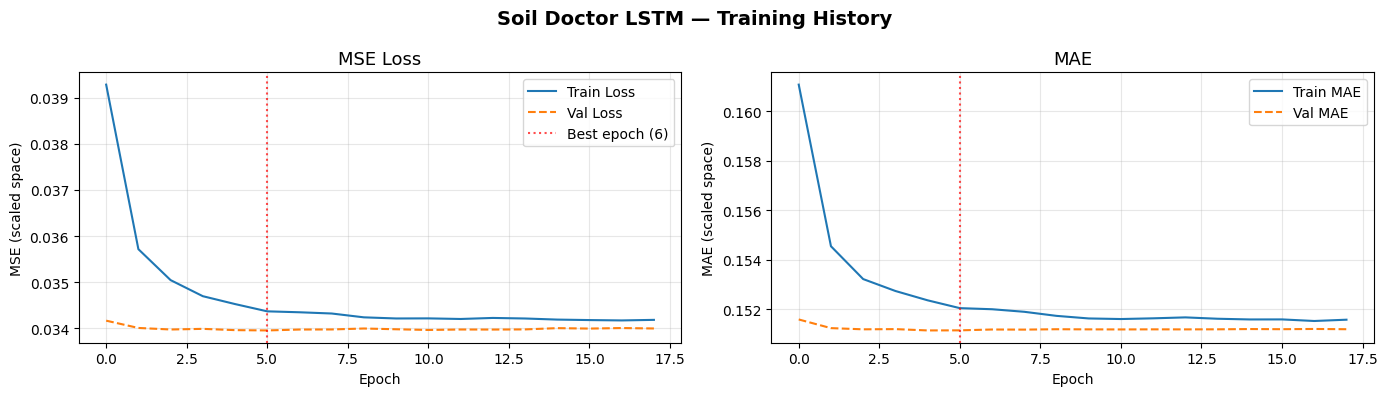

Saved → training_history.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss (MSE)
axes[0].plot(history.history["loss"],     label="Train Loss", linewidth=1.5)
axes[0].plot(history.history["val_loss"], label="Val Loss",   linewidth=1.5, linestyle="--")
best_epoch = int(np.argmin(history.history["val_loss"]))
axes[0].axvline(best_epoch, color="red", linestyle=":", alpha=0.7, label=f"Best epoch ({best_epoch+1})")
axes[0].set_title("MSE Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled space)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history["mae"],     label="Train MAE", linewidth=1.5)
axes[1].plot(history.history["val_mae"], label="Val MAE",   linewidth=1.5, linestyle="--")
axes[1].axvline(best_epoch, color="red", linestyle=":", alpha=0.7)
axes[1].set_title("MAE", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (scaled space)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Soil Doctor LSTM — Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_history.png")

## Cell 10 — Evaluation on Test Set (Inverse-Transformed)

In [11]:
# ── Load the best checkpoint and predict ───────────────────────────────────
best_model = keras.saving.load_model(MODEL_PATH)

y_pred_scaled = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()

# ── Inverse-transform: rebuild a dummy array with the target column ────────
def inverse_transform_target(
    scaled_values: np.ndarray,
    scaler: MinMaxScaler,
    target_idx: int,
    n_features: int,
) -> np.ndarray:
    """
    Inverse-scale a 1-D array of predictions back to original units.
    Inserts the predictions into the target column of a zero-filled
    dummy array so the scaler's inverse_transform works correctly.
    """
    dummy = np.zeros((len(scaled_values), n_features), dtype=np.float32)
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]


y_pred_real = inverse_transform_target(y_pred_scaled, scaler, TARGET_IDX, N_FEATURES)
y_test_real = inverse_transform_target(y_test,        scaler, TARGET_IDX, N_FEATURES)

# ── Metrics ────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2   = r2_score(y_test_real, y_pred_real)

print("="*45)
print(f"  Test Set Evaluation  ({len(y_test_real)} samples)")
print("="*45)
print(f"  MAE  : {mae:.4f}  (original units)")
print(f"  RMSE : {rmse:.4f}  (original units)")
print(f"  R²   : {r2:.4f}")
print("="*45)

  Test Set Evaluation  (2990 samples)
  MAE  : 11.9850  (original units)
  RMSE : 14.6927  (original units)
  R²   : -0.0026


## Cell 11 — Actual vs Predicted Plot

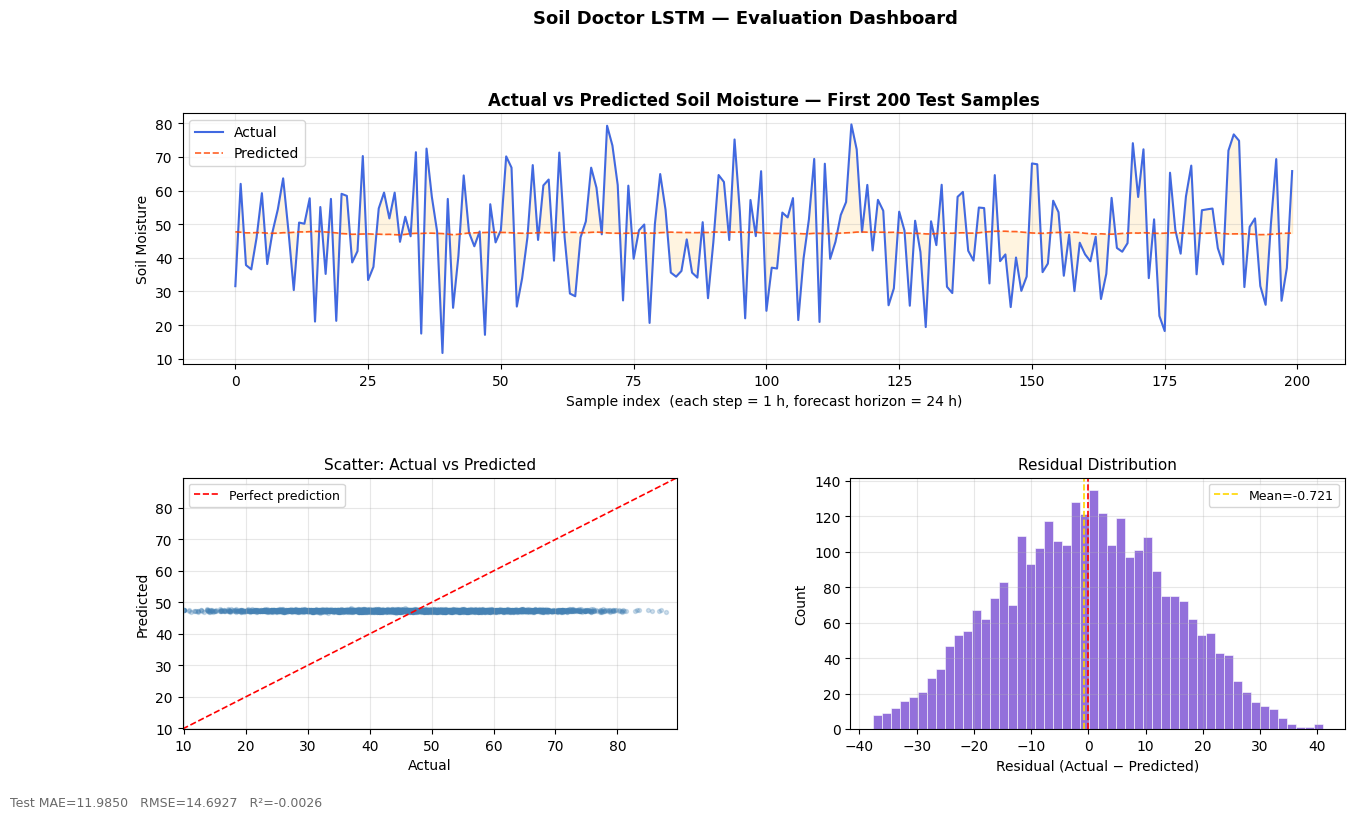

Saved → evaluation_dashboard.png


In [12]:
n_plot = min(PLOT_SAMPLES, len(y_test_real))
idx    = np.arange(n_plot)

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Top: time-series overlay ───────────────────────────────────────────────
ax_ts = fig.add_subplot(gs[0, :])
ax_ts.plot(idx, y_test_real[:n_plot], label="Actual",    color="royalblue",  linewidth=1.5)
ax_ts.plot(idx, y_pred_real[:n_plot], label="Predicted", color="orangered",  linewidth=1.2, linestyle="--", alpha=0.85)
ax_ts.fill_between(
    idx,
    y_test_real[:n_plot],
    y_pred_real[:n_plot],
    alpha=0.12, color="orange",
)
ax_ts.set_title(f"Actual vs Predicted Soil Moisture — First {n_plot} Test Samples", fontsize=12, fontweight="bold")
ax_ts.set_xlabel(f"Sample index  (each step = 1 h, forecast horizon = {HORIZON} h)")
ax_ts.set_ylabel("Soil Moisture")
ax_ts.legend()
ax_ts.grid(alpha=0.3)

# ── Bottom-left: scatter plot ──────────────────────────────────────────────
ax_sc = fig.add_subplot(gs[1, 0])
ax_sc.scatter(y_test_real, y_pred_real, alpha=0.25, s=8, color="steelblue")
lims = [min(y_test_real.min(), y_pred_real.min()) * 0.98,
        max(y_test_real.max(), y_pred_real.max()) * 1.02]
ax_sc.plot(lims, lims, "r--", linewidth=1.2, label="Perfect prediction")
ax_sc.set_xlim(lims); ax_sc.set_ylim(lims)
ax_sc.set_xlabel("Actual"); ax_sc.set_ylabel("Predicted")
ax_sc.set_title("Scatter: Actual vs Predicted", fontsize=11)
ax_sc.legend(fontsize=9); ax_sc.grid(alpha=0.3)

# ── Bottom-right: residuals ────────────────────────────────────────────────
residuals = y_test_real - y_pred_real
ax_res = fig.add_subplot(gs[1, 1])
ax_res.hist(residuals, bins=50, color="mediumpurple", edgecolor="white", linewidth=0.4)
ax_res.axvline(0, color="red", linewidth=1.2, linestyle="--")
ax_res.axvline(residuals.mean(), color="gold", linewidth=1.2, linestyle="--", label=f"Mean={residuals.mean():.3f}")
ax_res.set_xlabel("Residual (Actual − Predicted)")
ax_res.set_ylabel("Count")
ax_res.set_title("Residual Distribution", fontsize=11)
ax_res.legend(fontsize=9); ax_res.grid(alpha=0.3)

# ── Metrics annotation ────────────────────────────────────────────────────
fig.text(
    0.01, 0.01,
    f"Test MAE={mae:.4f}   RMSE={rmse:.4f}   R²={r2:.4f}",
    fontsize=9, color="dimgray",
    verticalalignment="bottom",
)

plt.suptitle("Soil Doctor LSTM — Evaluation Dashboard", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → evaluation_dashboard.png")

## Cell 12 — FastAPI Inference Quickstart (Reference)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# This cell is DOCUMENTATION only — copy the snippet into your FastAPI service.
# It shows how to load the saved artefacts and run live inference.
# ─────────────────────────────────────────────────────────────────────────────

FASTAPI_SNIPPET = '''
import os
os.environ["KERAS_BACKEND"] = "torch"   # must be set before keras import

import numpy as np
import joblib
import keras

# ── Constants — must match training config ─────────────────────────────────
FEATURE_COLS = ["temperature", "humidity", "moisture", "N", "P", "K", "Rainfall"]
TARGET_IDX   = FEATURE_COLS.index("moisture")
N_FEATURES   = len(FEATURE_COLS)
LOOKBACK     = 48

# ── Load artefacts once at startup ─────────────────────────────────────────
scaler = joblib.load("scaler_moisture.pkl")
model  = keras.saving.load_model("lstm_moisture_model.keras")

def predict_moisture(window: list[dict]) -> float:
    """
    Parameters
    ----------
    window : list of 48 dicts, each with keys matching FEATURE_COLS
             in chronological order (oldest first).

    Returns
    -------
    Predicted moisture value in original units, 24 h ahead.
    """
    assert len(window) == LOOKBACK, f"Expected {LOOKBACK} rows, got {len(window)}"

    arr = np.array([[row[c] for c in FEATURE_COLS] for row in window], dtype=np.float32)
    arr_scaled = scaler.transform(arr)                   # (48, 7)
    X = arr_scaled[np.newaxis, ...]                      # (1, 48, 7)

    pred_scaled = model.predict(X, verbose=0).flatten()[0]

    # Inverse-transform the single predicted value
    dummy = np.zeros((1, N_FEATURES), dtype=np.float32)
    dummy[0, TARGET_IDX] = pred_scaled
    pred_real = scaler.inverse_transform(dummy)[0, TARGET_IDX]

    return float(pred_real)
'''

print(FASTAPI_SNIPPET)


import os
os.environ["KERAS_BACKEND"] = "torch"   # must be set before keras import

import numpy as np
import joblib
import keras

# ── Constants — must match training config ─────────────────────────────────
FEATURE_COLS = ["temperature", "humidity", "moisture", "N", "P", "K", "Rainfall"]
TARGET_IDX   = FEATURE_COLS.index("moisture")
N_FEATURES   = len(FEATURE_COLS)
LOOKBACK     = 48

# ── Load artefacts once at startup ─────────────────────────────────────────
scaler = joblib.load("scaler_moisture.pkl")
model  = keras.saving.load_model("lstm_moisture_model.keras")

def predict_moisture(window: list[dict]) -> float:
    """
    Parameters
    ----------
    window : list of 48 dicts, each with keys matching FEATURE_COLS
             in chronological order (oldest first).

    Returns
    -------
    Predicted moisture value in original units, 24 h ahead.
    """
    assert len(window) == LOOKBACK, f"Expected {LOOKBACK} rows, got {len(window)}"

    arr = np.array([[row[c] for c in F

---
### Artefacts produced by this notebook
| File | Purpose |
|---|---|
| `scaler_moisture.pkl` | `MinMaxScaler` — load in FastAPI for live inference |
| `lstm_moisture_model.keras` | Best LSTM checkpoint (native Keras format) |
| `training_history.png` | Loss / MAE curves |
| `evaluation_dashboard.png` | Actual-vs-Predicted + scatter + residuals |